In [37]:
import os
os.chdir(os.path.expanduser('~/market-workbench'))

import seaborn as sns
import yfinance as yf
import pandas as pd
import numpy as np
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

ticker = yf.Ticker('AAPL')
print(ticker.financials)
print(ticker.balance_sheet)
print(ticker.cashflow)

                                                      2025-09-30  \
Tax Effect Of Unusual Items                         0.000000e+00   
Tax Rate For Calcs                                  1.560000e-01   
Normalized EBITDA                                   1.447480e+11   
Net Income From Continuing Operation Net Minori...  1.120100e+11   
Reconciled Depreciation                             1.169800e+10   
Reconciled Cost Of Revenue                          2.209600e+11   
EBITDA                                              1.447480e+11   
EBIT                                                1.330500e+11   
Net Interest Income                                          NaN   
Interest Expense                                             NaN   
Interest Income                                              NaN   
Normalized Income                                   1.120100e+11   
Net Income From Continuing And Discontinued Ope...  1.120100e+11   
Total Expenses                                  

In [28]:
#Pull out revenue, fcf, and operating margin for each year
financials = ticker.financials
balance_sheet = ticker.balance_sheet
cashflow = ticker.cashflow
revenue = financials.loc['Total Revenue']
fcf = cashflow.loc['Free Cash Flow']
operating_income = financials.loc['Operating Income']
operating_margin = operating_income / revenue
#Combine into a single DataFrame
df = pd.DataFrame({
    'Revenue': revenue,
    'FCF': fcf,
    'Operating Margin': operating_margin
}).dropna()
print(df)

                 Revenue           FCF  Operating Margin
2025-09-30  4.161610e+11  9.876700e+10          0.319708
2024-09-30  3.910350e+11  1.088070e+11          0.315102
2023-09-30  3.832850e+11  9.958400e+10          0.298214
2022-09-30  3.943280e+11  1.114430e+11          0.302887


In [27]:
revenue_growth = revenue.pct_change(-1, fill_method=None).dropna() # -1 because yfinance orders newest first
print("Revenue Growth Rates:")
print(revenue_growth)
print(f"\nMean: {revenue_growth.mean():.4f}")
print(f"Std: {revenue_growth.std():.4f}")

print(f"\nOperating Margin - Mean: {operating_margin.mean():.4f}, Std: {operating_margin.std():.4f}")

Revenue Growth Rates:
2025-09-30    0.064255
2024-09-30    0.020220
2023-09-30   -0.028005
Name: Total Revenue, dtype: float64

Mean: 0.0188
Std: 0.0461

Operating Margin - Mean: 0.3090, Std: 0.0101


In [26]:
print(balance_sheet.index.tolist())

['Treasury Shares Number', 'Ordinary Shares Number', 'Share Issued', 'Net Debt', 'Total Debt', 'Tangible Book Value', 'Invested Capital', 'Working Capital', 'Net Tangible Assets', 'Capital Lease Obligations', 'Common Stock Equity', 'Total Capitalization', 'Total Equity Gross Minority Interest', 'Stockholders Equity', 'Gains Losses Not Affecting Retained Earnings', 'Other Equity Adjustments', 'Retained Earnings', 'Capital Stock', 'Common Stock', 'Total Liabilities Net Minority Interest', 'Total Non Current Liabilities Net Minority Interest', 'Other Non Current Liabilities', 'Tradeand Other Payables Non Current', 'Long Term Debt And Capital Lease Obligation', 'Long Term Capital Lease Obligation', 'Long Term Debt', 'Current Liabilities', 'Other Current Liabilities', 'Current Deferred Liabilities', 'Current Deferred Revenue', 'Current Debt And Capital Lease Obligation', 'Current Capital Lease Obligation', 'Current Debt', 'Other Current Borrowings', 'Commercial Paper', 'Payables And Accrued

In [29]:
#Build the WACC, using RFR from 10yr_treasury from data_fetcher.py, Beta from the stock, equity risk premium of 5%, and cost of debt from the balance sheet
from core.data_fetcher import get_risk_free_rate
rfr = get_risk_free_rate()
beta = ticker.info['beta']
equity_risk_premium = 0.05
cost_of_equity = rfr + beta * equity_risk_premium
total_debt = balance_sheet.loc['Total Debt'].iloc[0]
cash_and_equivalents = balance_sheet.loc['Cash And Cash Equivalents'].iloc[0]
total_equity = balance_sheet.loc['Stockholders Equity'].iloc[0]
net_debt = total_debt - cash_and_equivalents
debt_weight = net_debt / (net_debt + total_equity)
equity_weight = total_equity / (net_debt + total_equity)
interest_expense = financials.loc['Interest Expense'].dropna()
if len(interest_expense) > 0:
    cost_of_debt = abs(interest_expense.iloc[0]) / total_debt
else:
    # Try an older year where interest expense exists
    for i in range(len(financials.columns)):
        val = financials.loc['Interest Expense'].iloc[i]
        if not pd.isna(val):
            cost_of_debt = abs(val) / total_debt
            break
    else:
        cost_of_debt = rfr + 0.01  # Risk-free rate + 1% credit spread as last resort
wacc = debt_weight * cost_of_debt * (1 - 0.21) + equity_weight * cost_of_equity
print(f"\nWACC: {wacc:.4f}")
print(f"RFR: {rfr}")
print(f"Beta: {beta}")
print(f"Cost of equity: {cost_of_equity}")
print(f"Total debt: {total_debt}")
print(f"Cash: {cash_and_equivalents}")
print(f"Total equity: {total_equity}")
print(f"Interest expense: {financials.loc['Interest Expense'].iloc[0]}")


WACC: 0.0672
RFR: 0.0418
Beta: 1.116
Cost of equity: 0.0976
Total debt: 98657000000.0
Cash: 35934000000.0
Total equity: 73733000000.0
Interest expense: nan


In [31]:
#Build the DCF projection Terminal value via Gordon Growth Model Implied share price = Σ(discounted FCFs) + discounted terminal value / shares outstanding
#Make sure to compute for all years
shares_outstanding = ticker.info['sharesOutstanding']
growth_rate = revenue_growth.mean()
projection_years = 5
discounted_fcfs = []
for i in range(projection_years):
    projected_fcf = fcf.iloc[0] * (1 + growth_rate) ** (i + 1)
    discounted_fcf = projected_fcf / (1 + wacc) ** (i + 1)
    discounted_fcfs.append(discounted_fcf)
terminal_growth = 0.025  # 2.5% perpetual growth (GDP proxy)
terminal_value = (fcf.iloc[0] * (1 + growth_rate) ** projection_years * (1 + terminal_growth)) / (wacc - terminal_growth)
discounted_terminal_value = terminal_value / (1 + wacc) ** projection_years
intrinsic_value = sum(discounted_fcfs) + discounted_terminal_value
implied_share_price = intrinsic_value / shares_outstanding
print(f"\nImplied Share Price: {implied_share_price:.2f}")


Implied Share Price: 158.86


In [33]:
#Build out the Monte Carlo simulation for the DCF, varying revenue growth rate, operating margin and WACC
#Do not use plain normal distributions | revenue growth: truncated normal or beta distribution | operating margin: beta distribution | WACC: triangular distribution
import scipy.stats as stats
num_simulations = 10000
simulated_prices = []
# Define distributions
revenue_growth_dist = stats.truncnorm(
    (-0.10 - revenue_growth.mean()) / revenue_growth.std(),  # floor: -10% 
    (0.15 - revenue_growth.mean()) / revenue_growth.std(),   # ceiling: +15%
    loc=revenue_growth.mean(), 
    scale=revenue_growth.std())
operating_margin_dist = stats.beta((operating_margin.mean() * (1 - operating_margin.mean())) / operating_margin.var() - 1, ((1 - operating_margin.mean()) * operating_margin.mean()) / operating_margin.var() - 1, loc=operating_margin.min(), scale=operating_margin.max() - operating_margin.min())
wacc_low = wacc - 0.02
wacc_high = wacc + 0.02
wacc_dist = stats.triang(c=0.5, loc=wacc_low, scale=wacc_high - wacc_low)  # peak in the middle

fcf_margin_mean = (fcf / revenue).dropna().mean()

for _ in range(num_simulations):
    sim_revenue_growth = revenue_growth_dist.rvs()
    sim_operating_margin = operating_margin_dist.rvs()
    sim_wacc = wacc_dist.rvs()
    
    sim_discounted_fcfs = []
    for i in range(projection_years):
        projected_revenue = revenue.iloc[0] * (1 + sim_revenue_growth) ** (i + 1)
        projected_fcf = projected_revenue * fcf_margin_mean
        discounted_fcf = projected_fcf / (1 + sim_wacc) ** (i + 1)
        sim_discounted_fcfs.append(discounted_fcf)

    if sim_wacc <= terminal_growth:
        continue  # skip this simulation
    sim_terminal_value = (projected_fcf * (1 + terminal_growth)) / (sim_wacc - terminal_growth)
    discounted_terminal_value = sim_terminal_value / (1 + sim_wacc) ** projection_years
    sim_intrinsic_value = sum(sim_discounted_fcfs) + discounted_terminal_value
    sim_implied_share_price = sim_intrinsic_value / shares_outstanding
    simulated_prices.append(sim_implied_share_price)
# Analyze simulation results
simulated_prices = np.array(simulated_prices)
print(f"\nMonte Carlo Simulation Results:")
print(f"Mean Implied Price: {simulated_prices.mean():.2f}")
print(f"Median Implied Price: {np.median(simulated_prices):.2f}")
print(f"5th Percentile: {np.percentile(simulated_prices, 5):.2f}")
print(f"95th Percentile: {np.percentile(simulated_prices, 95):.2f}")


Monte Carlo Simulation Results:
Mean Implied Price: 188.04
Median Implied Price: 178.78
5th Percentile: 115.09
95th Percentile: 292.45


In [34]:
current_price = ticker.info['currentPrice']
pct_undervalued = (simulated_prices > current_price).mean() * 100
print(f"Current Price: ${current_price:.2f}")
print(f"Simulations where stock is undervalued: {pct_undervalued:.1f}%")

Current Price: $251.49
Simulations where stock is undervalued: 12.8%


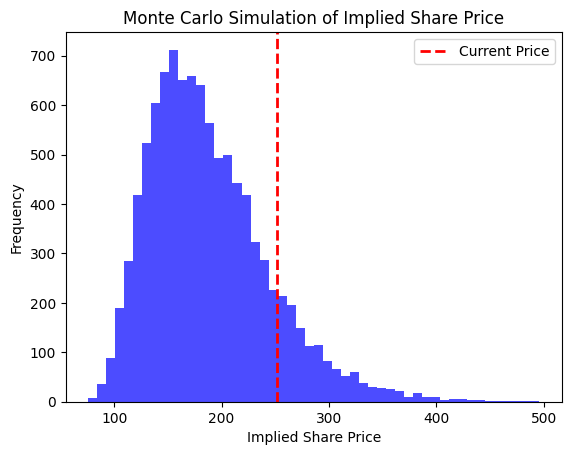

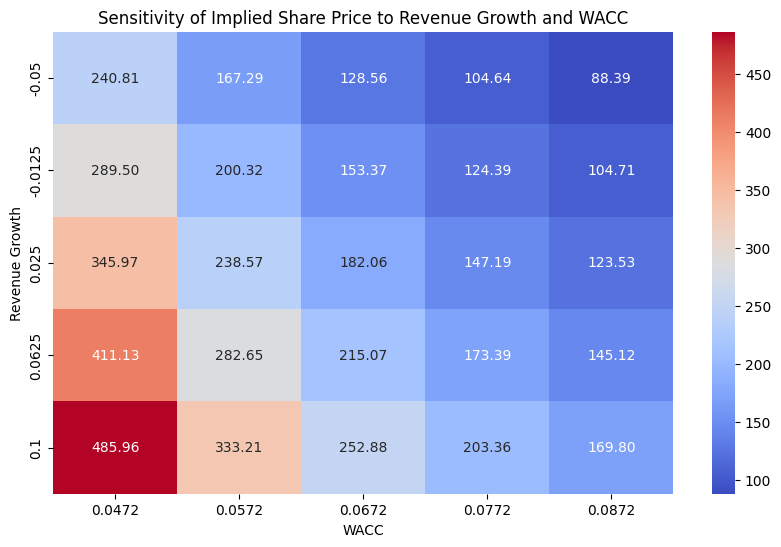

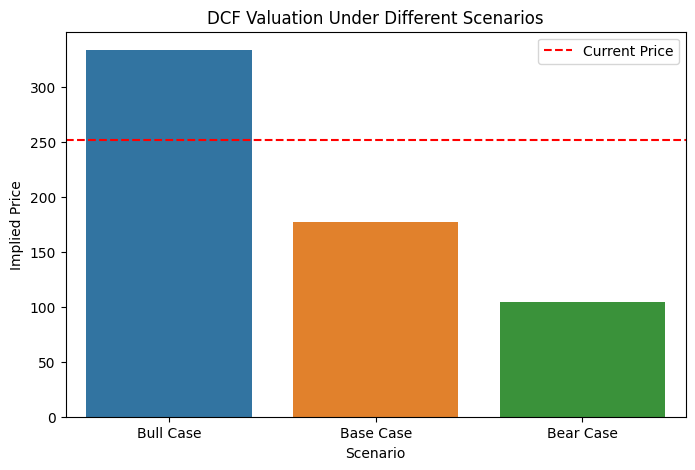

In [43]:
#Plot full distribution of implied prices
import matplotlib.pyplot as plt
plt.hist(simulated_prices, bins=50, alpha=0.7, color='blue')
plt.axvline(current_price, color='red', linestyle='dashed', linewidth=2, label='Current Price')
plt.title('Monte Carlo Simulation of Implied Share Price')
plt.xlabel('Implied Share Price')
plt.ylabel('Frequency')
plt.legend()
plt.show()
# Sensitivity heatmap, 2x2 heatmap of revenue growth rate x WACC, colored by implied price
import seaborn as sns
heatmap_data = []
revenue_growth_range = np.linspace(-0.05, 0.10, 5)  # -5% to +10%
wacc_range = np.linspace(wacc - 0.02, wacc + 0.02, 5)
for rg in revenue_growth_range:
    for w in wacc_range:
        discounted_fcfs = []
        for i in range(projection_years):
            projected_revenue = revenue.iloc[0] * (1 + rg) ** (i + 1)
            projected_fcf = projected_revenue * fcf_margin_mean
            discounted_fcf = projected_fcf / (1 + w) ** (i + 1)
            discounted_fcfs.append(discounted_fcf)
        if w <= terminal_growth:
            continue
        terminal_value = (projected_fcf * (1 + terminal_growth)) / (w - terminal_growth)
        discounted_terminal_value = terminal_value / (1 + w) ** projection_years
        intrinsic_value = sum(discounted_fcfs) + discounted_terminal_value
        implied_share_price = intrinsic_value / shares_outstanding
        heatmap_data.append({'Revenue Growth': rg, 'WACC': w, 'Implied Price': implied_share_price})
heatmap_df = pd.DataFrame(heatmap_data)
heatmap_df['Revenue Growth'] = heatmap_df['Revenue Growth'].round(4)
heatmap_df['WACC'] = heatmap_df['WACC'].round(4)
heatmap_pivot = heatmap_df.pivot(index='Revenue Growth', columns='WACC', values='Implied Price')
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_pivot, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Sensitivity of Implied Share Price to Revenue Growth and WACC')
plt.show()
# Grouped bar chart: bull case vs bear case vs base case scenario comparison
scenarios = {
    'Bull Case': {'Revenue Growth': 0.10, 'WACC': wacc - 0.01},
    'Base Case': {'Revenue Growth': revenue_growth.mean(), 'WACC': wacc},
    'Bear Case': {'Revenue Growth': -0.05, 'WACC': wacc + 0.01}
}
scenario_prices = {}
for scenario, params in scenarios.items():
    rg = params['Revenue Growth']
    w = params['WACC']
    discounted_fcfs = []
    for i in range(projection_years):
        projected_revenue = revenue.iloc[0] * (1 + rg) ** (i + 1)
        projected_fcf = projected_revenue * fcf_margin_mean
        discounted_fcf = projected_fcf / (1 + w) ** (i + 1)
        discounted_fcfs.append(discounted_fcf)
    if w <= terminal_growth:
        scenario_prices[scenario] = np.nan
        continue
    terminal_value = (projected_fcf * (1 + terminal_growth)) / (w - terminal_growth)
    discounted_terminal_value = terminal_value / (1 + w) ** projection_years
    intrinsic_value = sum(discounted_fcfs) + discounted_terminal_value
    implied_share_price = intrinsic_value / shares_outstanding
    scenario_prices[scenario] = implied_share_price
scenario_df = pd.DataFrame(list(scenario_prices.items()), columns=['Scenario', 'Implied Price'])
plt.figure(figsize=(8, 5))
sns.barplot(x='Scenario', y='Implied Price', data=scenario_df, hue='Scenario', legend=False)
plt.axhline(current_price, color='red', linestyle='dashed', label='Current Price')
plt.title('DCF Valuation Under Different Scenarios')
plt.legend()
plt.show()


Shapiro-Wilk Test for Operating Margin:
Statistic: 0.9240, p-value: 0.5595


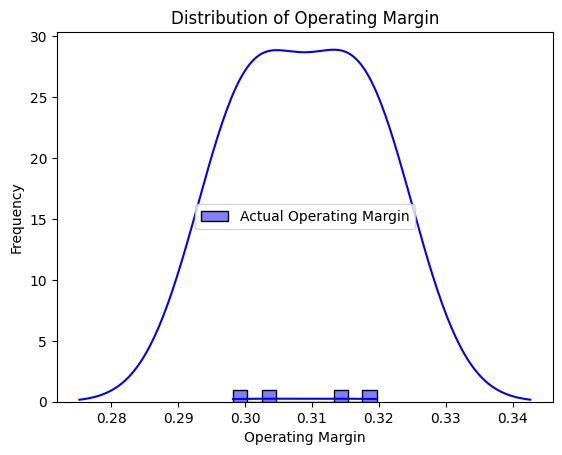

In [44]:
#Do Shapiro-Wilk test on historical operating margin to check for normality
#Plot of actual distribution vs modeled distribution
from scipy.stats import shapiro
stat, p_value = shapiro(operating_margin.dropna())
print(f"\nShapiro-Wilk Test for Operating Margin:")
print(f"Statistic: {stat:.4f}, p-value: {p_value:.4f}")
sns.histplot(operating_margin.dropna(), bins=10, kde=True, color='blue', label='Actual Operating Margin')
sns.kdeplot(operating_margin.dropna(), color='blue')
plt.title('Distribution of Operating Margin')
plt.xlabel('Operating Margin')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Our DCF was wrong, we need to build it using operating income minus capex.

In [ ]:
def weighted_mean(series):
    '''Weigh recent years more heavily.'''
    clean = series.dropna()
    if len(clean) <= 1:
        return float(clean.mean())
    weights = np.arrange(len(clean), 0, -1)
    return float(np.average(clean, weights=weights))

def get_fcf_components(ticker_symbol):
    '''Extract all the components we will need from financial statements
    to build FCF from the ground up.
    '''
    t = yf.ticker(ticker_symbol)
    financials = t.financials
    cashflow = t.cashflow

    revenue = financials.loc['Total Revenue']
    op_inc  = financials.loc['Operating Income']
    tax_rate = financials.loc['Tax Rate for Calcs']
    depreciation = cashflow.loc['Depreciation and Amortization']
    capex = cashflow.loc['Capital Expenditure'].abs()
    wc_change = cashflow.loc['Change In Working Capital']

    op_marg = op_inc / revenue
    da_ratio = depreciation / revenue
    capex_ratio = capex / revenue
    wc_ratio = wc_change / revenue

    nopat = op_inc * (1 - tax_rate)
    build_fcf = nopat + depreciation - capex - wc_change
    build_fcf_margin = build_fcf / revenue

    return {
        'revenue': revenue,
        'op_margin': weighted_mean(op_margin),
        'tax_rate': weighted_mean(tax_rate),
        'da_ratio': weighted_mean(da_ratio), 
        'capex_ratio': weighted_mean(capex_ratio),
        'wc_ratio': weighted_mean(wc_ratio),
        'build_fcf_margin': weighted_mean(build_fcf_margin),
        'raw_fcf_margin': weighted_mean(cashflow.loc['Free Cash Flow'] / revenue)
        }

